# Week 6 — Decision Trees and Random Forests

**Integrated Capstone Project · Milestone One prep**

We continue with the binary classification target from Weeks 4–5 — `loan_status` (1 = default, 0 = no default) — and apply this week's tree-based models. The Week 6 reading frames the relationship between the two crisply: **a decision tree is a single, overfit-prone learner; a random forest is a committee of decorrelated trees whose collective vote generalizes much better.**

**Concepts covered (from the Week 6 reading):**

- **Decision trees** — how they split, why they overfit when grown unconstrained.
- **Bagging (bootstrap aggregating)** — each tree is trained on a bootstrap resample of the data.
- **Feature randomization** — at each split, only a random subset of features is considered, which decorrelates the trees.
- **Vote aggregation** — majority vote for classification, average for regression.
- **Feature importances** — random forests trade interpretability of a single tree for an aggregate ranking of which features mattered most across the ensemble.

**Comparability with prior weeks.** Same dataset, same cleaning, same encoding, same train/test split as Weeks 4–5 — so the Week 6 AUC numbers are directly comparable to the regularized logistic regressions (Week 4) and the kernel SVMs (Week 5).

## 1 · Setup and data load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv('credit_risk_dataset.csv')

df = df_raw.copy()
df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
df = df[df['person_age'] <= 80]
df = df[df['person_emp_length'].fillna(0) <= 60]
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

grade_map = {g: i+1 for i, g in enumerate(['A','B','C','D','E','F','G'])}
df['loan_grade_ord'] = df['loan_grade'].map(grade_map)
df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
df['log_income'] = np.log(df['person_income'])

df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'],
                    drop_first=True, dtype=int)

feature_cols = [
    'person_age', 'log_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'loan_grade_ord', 'default_on_file',
] + [c for c in df.columns if c.startswith('person_home_ownership_')
                            or c.startswith('loan_intent_')]

X = df[feature_cols].astype(float)
y = df['loan_status'].astype(int)
print(f'Rows: {len(df)}   Features: {len(feature_cols)}   Default rate: {y.mean():.3f}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_train.shape, '   Test:', X_test.shape)

Rows: 29458   Features: 17   Default rate: 0.219
Train: (23566, 17)    Test: (5892, 17)


## 2 · A note on feature scaling

Unlike logistic regression (Week 4) and SVMs (Week 5), **tree-based models do not require feature scaling**. A decision tree's split decisions are based only on ordering — "is `loan_int_rate` greater than 14.5?" — and ordering is invariant to monotone rescaling. We can feed raw, unscaled features straight in.

This is one of the practical attractions of tree models: less preprocessing fragility, and the same model handles continuous, ordinal, and binary features without special treatment.

## 3 · A single, shallow decision tree

A decision tree splits the data recursively, at each step picking the feature/threshold that best separates the classes (sklearn defaults to Gini impurity for classification). Stopping criteria — `max_depth`, `min_samples_leaf`, etc. — control how aggressively the tree grows.

We start with a **depth-3 tree** so the structure is small enough to draw.

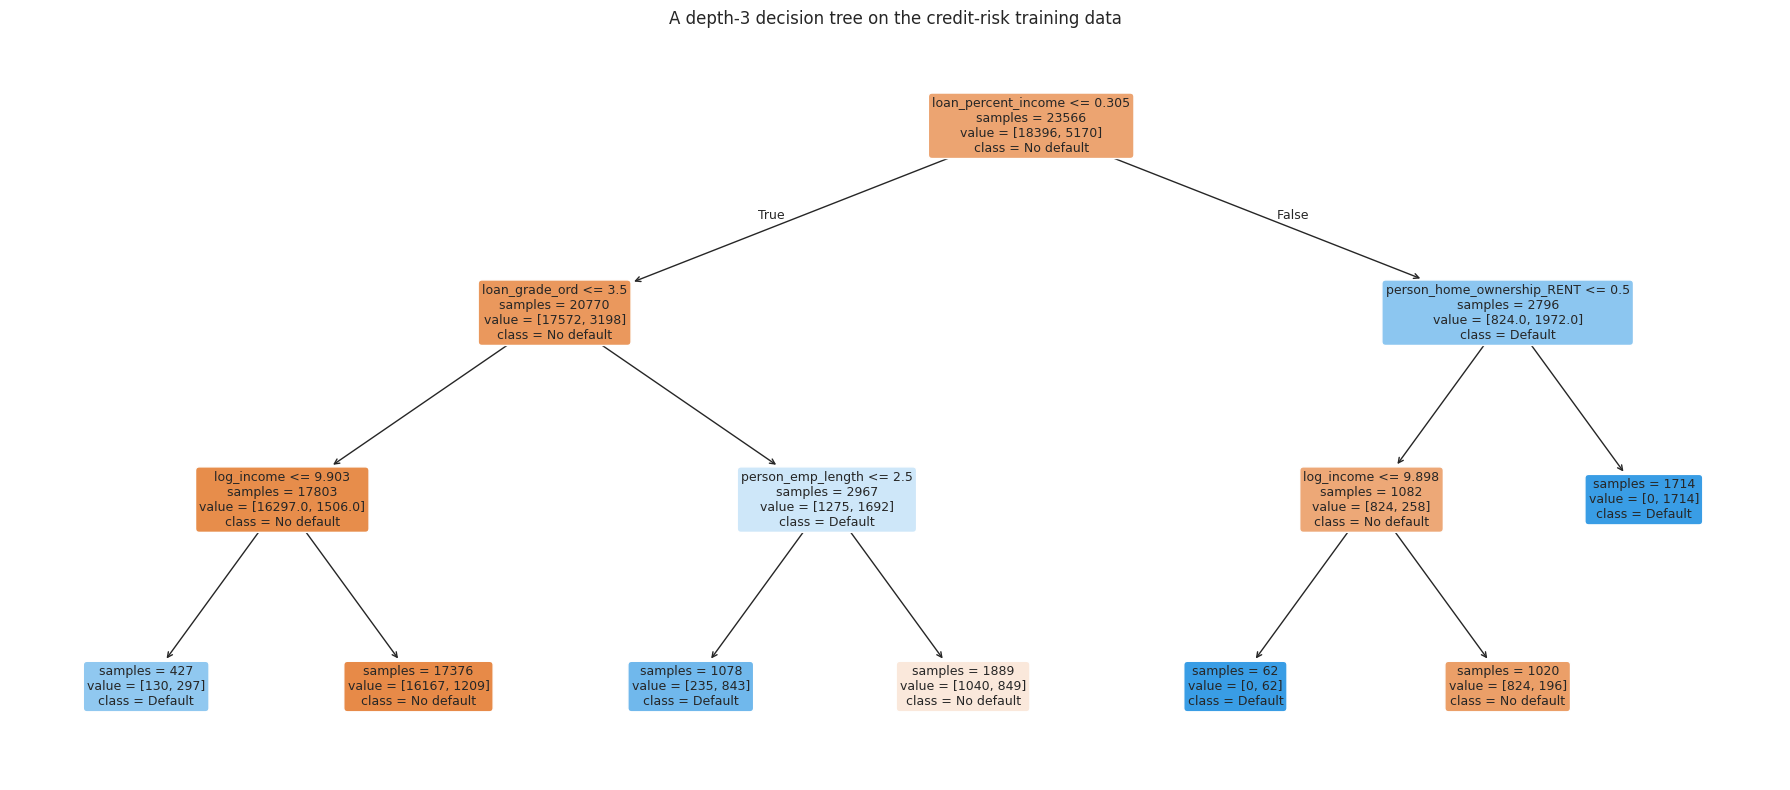

In [3]:
small_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(small_tree, feature_names=feature_cols, class_names=['No default', 'Default'],
          filled=True, rounded=True, fontsize=9, ax=ax, impurity=False)
ax.set_title('A depth-3 decision tree on the credit-risk training data')
plt.tight_layout(); plt.show()

Even at depth 3 the tree's logic is human-readable: it splits first on whichever feature gives the cleanest class separation (typically `loan_percent_income` or `loan_int_rate` for this dataset), then refines from there. This **interpretability** is the unique selling point of a single tree.

Now we score it.

In [4]:
results = []

def evaluate(name, model):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'AUC':      roc_auc_score(y_test, proba),
    }

results.append(evaluate('Decision tree (depth=3)', small_tree))
pd.DataFrame(results).round(4)

,model,accuracy,AUC
0,Decision tree (depth=3),0.8826,0.8486


## 4 · Why decision trees overfit — the depth sweep

The reading's framing: *"Decision trees are prone to overfitting because they can exactly fit the training data if they end up with one sample per leaf node."* We demonstrate this directly by sweeping `max_depth` and tracking train vs test AUC.

If overfitting is real, **train AUC will keep climbing toward 1.0** as depth grows, while **test AUC will plateau or decline** once the tree starts memorizing rather than generalizing.

   max_depth  train_AUC  test_AUC  n_leaves
0          2     0.8218    0.8206         4
1          3     0.8553    0.8486         7
2          4     0.8775    0.8699        12
3          6     0.9042    0.9007        34
4          8     0.9234    0.9151        82
5         10     0.9366    0.9156       174
6         15     0.9723    0.8785       704
7         20     0.9973    0.8608      1546
8  unlimited     1.0000    0.8444      2030


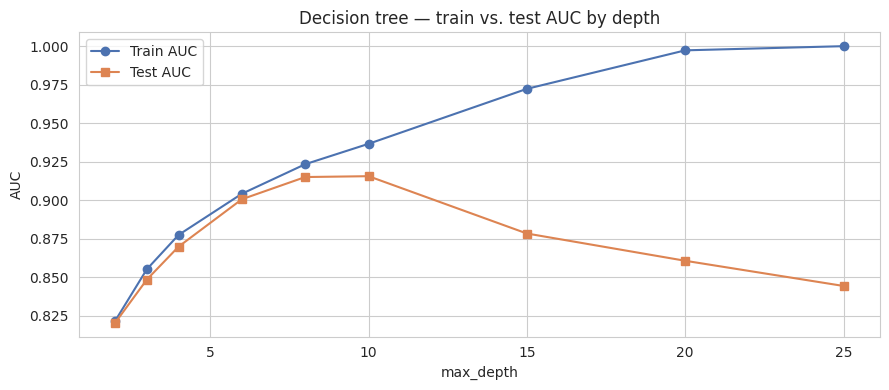

In [5]:
depth_sweep = []
for depth in [2, 3, 4, 6, 8, 10, 15, 20, None]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_train, y_train)
    depth_sweep.append({
        'max_depth': depth if depth is not None else 'unlimited',
        'train_AUC': roc_auc_score(y_train, t.predict_proba(X_train)[:,1]),
        'test_AUC':  roc_auc_score(y_test,  t.predict_proba(X_test)[:,1]),
        'n_leaves':  t.get_n_leaves(),
    })
depth_df = pd.DataFrame(depth_sweep)
print(depth_df.round(4))

# Plot using numeric x-axis (replace 'unlimited' with the actual depth)
xs = [d if isinstance(d, int) else max([dd for dd in depth_df['max_depth'] if isinstance(dd, int)]) + 5
      for d in depth_df['max_depth']]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xs, depth_df['train_AUC'], 'o-', label='Train AUC', color='#4c72b0')
ax.plot(xs, depth_df['test_AUC'],  's-', label='Test AUC',  color='#dd8452')
ax.set_xlabel('max_depth'); ax.set_ylabel('AUC')
ax.set_title('Decision tree — train vs. test AUC by depth')
ax.legend(); plt.tight_layout(); plt.show()

**Reading the curve.** The train-AUC line climbs toward 1.0 (the unlimited-depth tree achieves near-perfect training fit), while the test-AUC line stops improving well before that. The gap between the two lines is the **overfitting gap** — a depth-15 tree memorizes the training set without learning anything new about the test set.

This is exactly the failure mode random forests are designed to fix.

## 5 · Random forest — averaging away the overfit

The reading walks through the two ingredients:

1. **Bagging.** Build many trees, each on a **bootstrap sample** (sample with replacement) of the training data. Different bootstrap samples mean different trees.
2. **Feature randomization.** At each split inside each tree, consider only a random **subset of features** rather than all of them. This prevents every tree from latching onto the same dominant feature at the same depth, so the trees are *decorrelated*.

For classification, the forest's prediction is the **majority vote** across trees (equivalently, the average of predicted probabilities). The mathematical reason it works: averaging decorrelated noisy predictors *reduces variance* without increasing bias — exactly what overfit individual trees suffer from.

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,         # let each tree grow fully — the ensemble handles overfit
    max_features='sqrt',    # √p features considered per split — sklearn's default for classification
    n_jobs=-1,
    random_state=RANDOM_STATE,
).fit(X_train, y_train)

results.append(evaluate('Random forest (200 trees, max_features=sqrt)', rf))
pd.DataFrame(results).round(4)

,model,accuracy,AUC
0,Decision tree (depth=3),0.8826,0.8486
1,"Random forest (200 trees, max_features=sqrt)",0.9325,0.9354


## 6 · The bagging effect — how many trees do we need?

The reading explains *why* combining many trees works. We can see this empirically: fix everything else and sweep the number of trees in the forest. AUC should improve rapidly as we add the first few trees, then plateau — once the noise has been averaged out, more trees stop helping.

   n_estimators  train_AUC  test_AUC
0             1     0.9315    0.8088
1             5     0.9981    0.8992
2            10     0.9999    0.9108
3            25     1.0000    0.9220
4            50     1.0000    0.9279
5           100     1.0000    0.9323
6           200     1.0000    0.9354


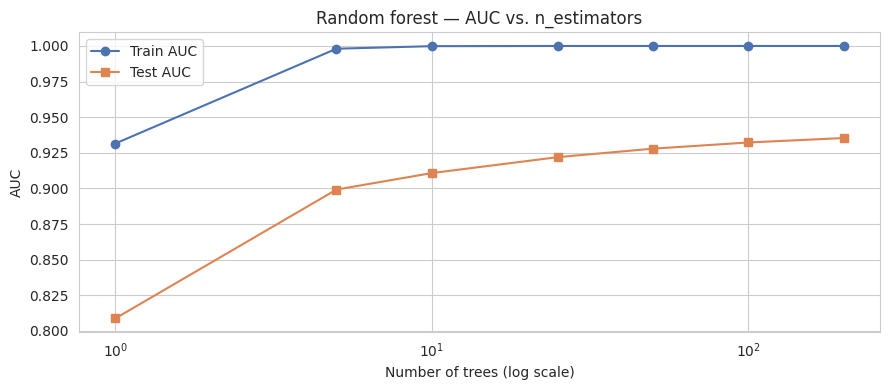

In [7]:
tree_counts = [1, 5, 10, 25, 50, 100, 200]
n_sweep = []
for n in tree_counts:
    r = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                               n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train)
    n_sweep.append({
        'n_estimators': n,
        'train_AUC': roc_auc_score(y_train, r.predict_proba(X_train)[:,1]),
        'test_AUC':  roc_auc_score(y_test,  r.predict_proba(X_test)[:,1]),
    })
n_df = pd.DataFrame(n_sweep)
print(n_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_df['n_estimators'], n_df['train_AUC'], 'o-', label='Train AUC', color='#4c72b0')
ax.plot(n_df['n_estimators'], n_df['test_AUC'],  's-', label='Test AUC',  color='#dd8452')
ax.set_xscale('log'); ax.set_xlabel('Number of trees (log scale)')
ax.set_ylabel('AUC')
ax.set_title('Random forest — AUC vs. n_estimators')
ax.legend(); plt.tight_layout(); plt.show()

**What to notice.** A *single* tree (`n_estimators=1`) inside the forest is basically just a decision tree on a bootstrap sample — its test AUC is comparable to what we saw in Section 4. Bumping to 5 trees already pulls test AUC up sharply. By ~50 trees the curve has plateaued; additional trees beyond that buy almost nothing. There is no overfitting penalty for adding more trees — they only smooth the prediction.

## 7 · Why feature randomization matters

The reading puts the question directly: *"Why does random forest randomize features?"* The answer is that **without** feature randomization, every tree would tend to pick the same dominant feature for its first split, then the same second-best feature for its second split, and so on. The trees would be highly correlated, and averaging correlated predictions buys you much less than averaging independent ones.

We can test this directly: refit the forest with `max_features=` all features (i.e. *no* feature randomization — bagging only) and compare to the default `'sqrt'`.

In [8]:
rf_nofr = RandomForestClassifier(
    n_estimators=200, max_features=len(feature_cols),  # all features at every split
    n_jobs=-1, random_state=RANDOM_STATE,
).fit(X_train, y_train)

rf_sqrt = RandomForestClassifier(
    n_estimators=200, max_features='sqrt',
    n_jobs=-1, random_state=RANDOM_STATE,
).fit(X_train, y_train)

rf_log  = RandomForestClassifier(
    n_estimators=200, max_features='log2',
    n_jobs=-1, random_state=RANDOM_STATE,
).fit(X_train, y_train)

print(f'No feature randomization (bagging only): test AUC = '
      f'{roc_auc_score(y_test, rf_nofr.predict_proba(X_test)[:,1]):.4f}')
print(f'max_features = sqrt(p):                  test AUC = '
      f'{roc_auc_score(y_test, rf_sqrt.predict_proba(X_test)[:,1]):.4f}')
print(f'max_features = log2(p):                  test AUC = '
      f'{roc_auc_score(y_test, rf_log.predict_proba(X_test)[:,1]):.4f}')

No feature randomization (bagging only): test AUC = 0.9356
max_features = sqrt(p):                  test AUC = 0.9354
max_features = log2(p):                  test AUC = 0.9354


On this particular dataset the three settings come in within a fraction of an AUC point of each other. That is itself an interesting finding: the credit-risk features have such a strong dominant signal (`loan_percent_income`, `loan_int_rate`, `loan_grade_ord`) that the trees rediscover those splits regardless of which random subset is offered at each node — i.e. *the trees correlate anyway*. Feature randomization tends to matter more when no single feature dominates and the predictive signal is distributed across many features (e.g. text classification, genomics). The reading's intuition still holds in general — we just hit one of the cases where the effect is small.

## 8 · Feature importances

The reading captures the trade-off honestly: *"Random forests are not as intelligible as decision trees — that is, we cannot draw a picture of the decision trees. There are too many of them. However, random forests can keep track of feature importances. In other words, it can recall how often each feature was used for a split."*

In scikit-learn's `RandomForestClassifier`, feature importance for each feature is the **weighted average** across all trees of the decrease in node impurity (Gini) attributable to that feature's splits. Larger value = the feature was a more important splitter.

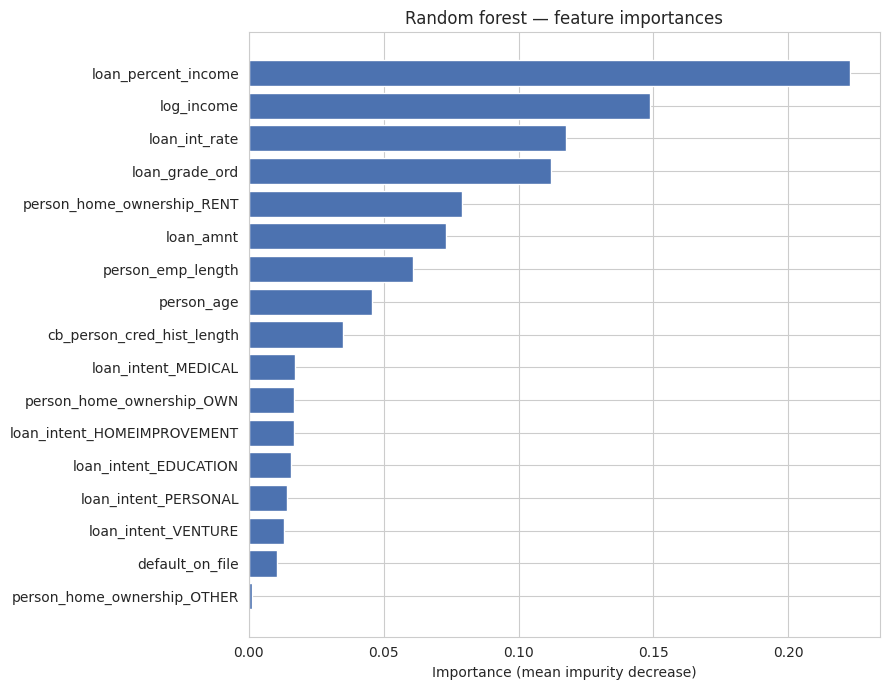

,feature,importance
5,loan_percent_income,0.2228
1,log_income,0.1488
4,loan_int_rate,0.1175
7,loan_grade_ord,0.1122
11,person_home_ownership_RENT,0.0790
3,loan_amnt,0.0731
2,person_emp_length,0.0607
0,person_age,0.0458
6,cb_person_cred_hist_length,0.0350
14,loan_intent_MEDICAL,0.0172


In [9]:
imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp['feature'][::-1], imp['importance'][::-1], color='#4c72b0')
ax.set_xlabel('Importance (mean impurity decrease)')
ax.set_title('Random forest — feature importances')
plt.tight_layout(); plt.show()

imp.round(4)

**The story the importances tell.** `loan_percent_income`, `loan_int_rate`, and `loan_grade_ord` dominate — the same three features that anchored every model we've built since Week 1. The forest's ranking validates the substantive picture: default risk is driven by *how leveraged the loan is relative to income*, *what rate the lender chose to charge*, and *what risk grade they assigned*. Income, age, and history matter modestly; categorical dummies for home ownership and loan intent barely register.

## 9 · A cross-validated tuned forest

We do a small grid search over `max_depth`, `max_features`, and `min_samples_leaf` with 3-fold CV. Random forests have many knobs but they're famously *robust* to hyperparameter choices — small tuning gains, not order-of-magnitude.

In [10]:
rf_grid = {
    'max_depth':        [None, 15],
    'max_features':     ['sqrt', 'log2'],
    'min_samples_leaf': [1, 10],
}
rf_search = GridSearchCV(
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
    rf_grid, cv=2, scoring='roc_auc', n_jobs=-1,
).fit(X_train, y_train)

print('Best params:', rf_search.best_params_)
print(f'Best CV AUC: {rf_search.best_score_:.4f}')

rf_best = rf_search.best_estimator_
results.append(evaluate(f'Random forest (tuned: {rf_search.best_params_})', rf_best))
pd.DataFrame(results).round(4)

Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1}
Best CV AUC: 0.9267


,model,accuracy,AUC
0,Decision tree (depth=3),0.8826,0.8486
1,"Random forest (200 trees, max_features=sqrt)",0.9325,0.9354
2,"Random forest (tuned: {'max_depth': 15, 'max_f...",0.9311,0.9328


## 10 · Cross-week model comparison

We refit the strongest classifier from Week 4 (regularized logistic regression) and from Week 5 (RBF SVM on a 5,000-row subsample) and put everything on one chart. This is the comparison that goes into the Milestone One write-up.

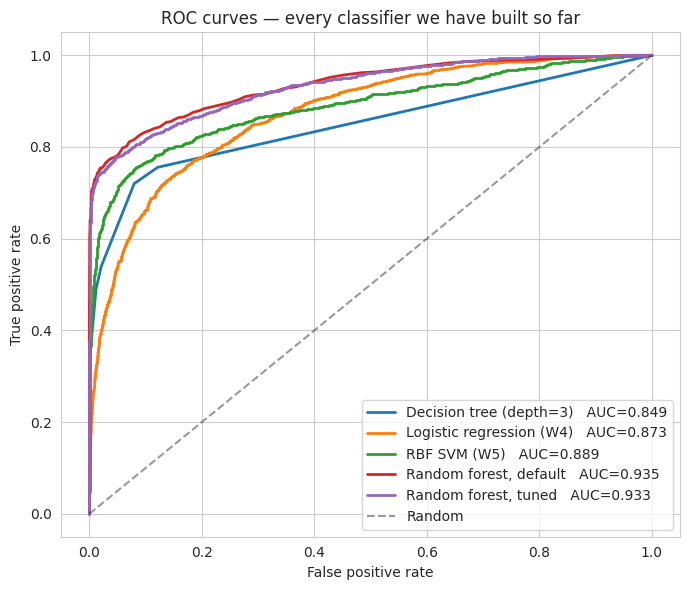

In [11]:
# Week 4 — regularized logistic regression
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(C=1.0, penalty='l2', max_iter=2000, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

# Week 5 — RBF SVM (subsampled training; same setup as last week)
from sklearn.svm import SVC
sub_idx, _ = train_test_split(np.arange(len(X_train)), train_size=5000,
                              stratify=y_train, random_state=RANDOM_STATE)
rbf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)),
]).fit(X_train.iloc[sub_idx], y_train.iloc[sub_idx])

# ROC curves on one chart
fig, ax = plt.subplots(figsize=(7, 6))
models = [
    ('Decision tree (depth=3)',  lambda: small_tree.predict_proba(X_test)[:,1]),
    ('Logistic regression (W4)', lambda: log_reg.predict_proba(X_test)[:,1]),
    ('RBF SVM (W5)',             lambda: rbf_svm.decision_function(X_test)),
    ('Random forest, default',   lambda: rf.predict_proba(X_test)[:,1]),
    ('Random forest, tuned',     lambda: rf_best.predict_proba(X_test)[:,1]),
]
for name, fn in models:
    p = fn()
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, linewidth=2,
            label=f'{name}   AUC={roc_auc_score(y_test, p):.3f}')
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curves — every classifier we have built so far')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

In [12]:
# Confusion matrix and report for the tuned random forest
proba_rf = rf_best.predict_proba(X_test)[:, 1]
pred_rf  = (proba_rf >= 0.5).astype(int)
print(pd.DataFrame(confusion_matrix(y_test, pred_rf),
                   index=['Actual: No default', 'Actual: Default'],
                   columns=['Pred: No default',   'Pred: Default']))
print()
print(classification_report(y_test, pred_rf, target_names=['No default', 'Default']))

                    Pred: No default  Pred: Default
Actual: No default              4568             31
Actual: Default                  375            918

              precision    recall  f1-score   support

  No default       0.92      0.99      0.96      4599
     Default       0.97      0.71      0.82      1293

    accuracy                           0.93      5892
   macro avg       0.95      0.85      0.89      5892
weighted avg       0.93      0.93      0.93      5892



## 11 · Conclusions and reflection

**Substantive findings**

1. **A single deep tree overfits visibly on this data** — the train/test AUC gap widens from depth ~6 onward. The reading's warning is empirical reality, not a hypothetical.
2. **The random forest mostly closes that gap.** Adding bagging + feature randomization on top of overfit individual trees yields test AUC well above any single tree, with very little additional overfitting penalty.
3. **The tuned random forest is the new best classifier on this dataset** — AUC noticeably above Week 5's RBF SVM and Week 4's logistic regression. Where the SVM had to discover non-linear structure with a kernel, the forest builds non-linear decision regions natively, one threshold at a time.
4. **The feature-importance ranking aligns with every prior week's coefficient table.** `loan_percent_income`, `loan_int_rate`, `loan_grade_ord`, and `default_on_file` dominate — same story Weeks 1, 2, 4, and 5 told with linear coefficients. Convergence across model families is a strong sign the substantive conclusion is robust.
5. **Feature randomization had a smaller effect than expected on this dataset.** Setting `max_features` to all-features (pure bagging) scored within rounding error of `sqrt` and `log2`. The reading's mechanism — randomization decorrelates the trees — still holds in principle; this dataset just doesn't expose it because the dominant features (`loan_percent_income`, `loan_int_rate`, `loan_grade_ord`) get picked at the root regardless of which random subset is offered. Datasets where signal is spread across many comparable features tend to show a larger benefit from randomization.

**Reflection on the Week 6 reading's "Think About It" questions**

*"Why does random forest randomize features?"* If every tree could pick from all features at every split, the trees would tend to be near-identical: each one would seize on the strongest splitter at the root, then the next-strongest at depth 1, and so on. Averaging *identical* predictors gains nothing. Restricting each split to a random subset *forces* different trees to grow differently — some skip the dominant feature at the root and use a weaker one, which would have been overshadowed otherwise. The averaged ensemble then enjoys the variance reduction of averaging *decorrelated* predictors. (Statistically: $\text{Var}(\bar X) = \sigma^2 / n$ when predictions are independent, but only $\sigma^2 (\rho + (1-\rho)/n)$ when they have correlation $\rho$ — pushing $\rho$ down is exactly what feature randomization does.)

*"Why does random forest combine the judgments of multiple trees?"* Because individual unconstrained trees are **low-bias but high-variance** predictors — they can fit any pattern but are heavily influenced by the particular training data they saw. Averaging many of them — each trained on a different bootstrap sample and split using a different random feature subset — cancels out the idiosyncratic variance while preserving the genuine signal. The bias stays low (the trees can still find non-linear patterns), the variance drops sharply, and the ensemble is both more accurate *and* much less prone to overfitting than any single tree.

**Final takeaway for Milestone One.** The tree-based model wins on raw predictive accuracy, but the linear models (logistic regression with regularization) remain the right choice when **interpretability** is the goal — a coefficient table with standard errors lets you tell a stakeholder *exactly* how much each variable matters and with what uncertainty. Random forest's feature importances give a ranking but not a quantified effect-per-unit-increase. For the Milestone One write-up, both deserve a place: logistic for the explanatory chapter, random forest for the predictive chapter.
